In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [31]:
pd.set_option('display.max_columns',None)

In [32]:
url = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/df_feat_eng.csv'
df = pd.read_csv(url)

In [33]:
df.loc[df['Location'] == 'Monte Carlo', 'Location'] = 'Monte Carlo, Monaco'

In [34]:
url_clima = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/weatherATP.csv'
df_clima = pd.read_csv(url_clima)

In [35]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')
df_clima['date'] = pd.to_datetime(df_clima['date'], format='%Y-%m-%d')

In [36]:
print(f'ANTES: Filas: df: {df.shape[0]}, columnas df: {df.shape[1]}')

df = df.merge(df_clima, left_on=['Fecha','Location'], right_on=['date','Ciudad'], how='inner')

print(f'DESPUES: Filas: df: {df.shape[0]}, columnas df: {df.shape[1]}')

ANTES: Filas: df: 16061, columnas df: 75
DESPUES: Filas: df: 16061, columnas df: 92


In [37]:
df = df.drop(columns=['date','Ciudad'])

Empezamos con un análisis univariado de variables categóricas y después pasamos directo al análisis de variables numéricas, que en la mayoría de los casos son variables que fueron creadas por mí. Por último, análisis bivariado y todos los análisis de la variable target.

## Análisis Categóricas

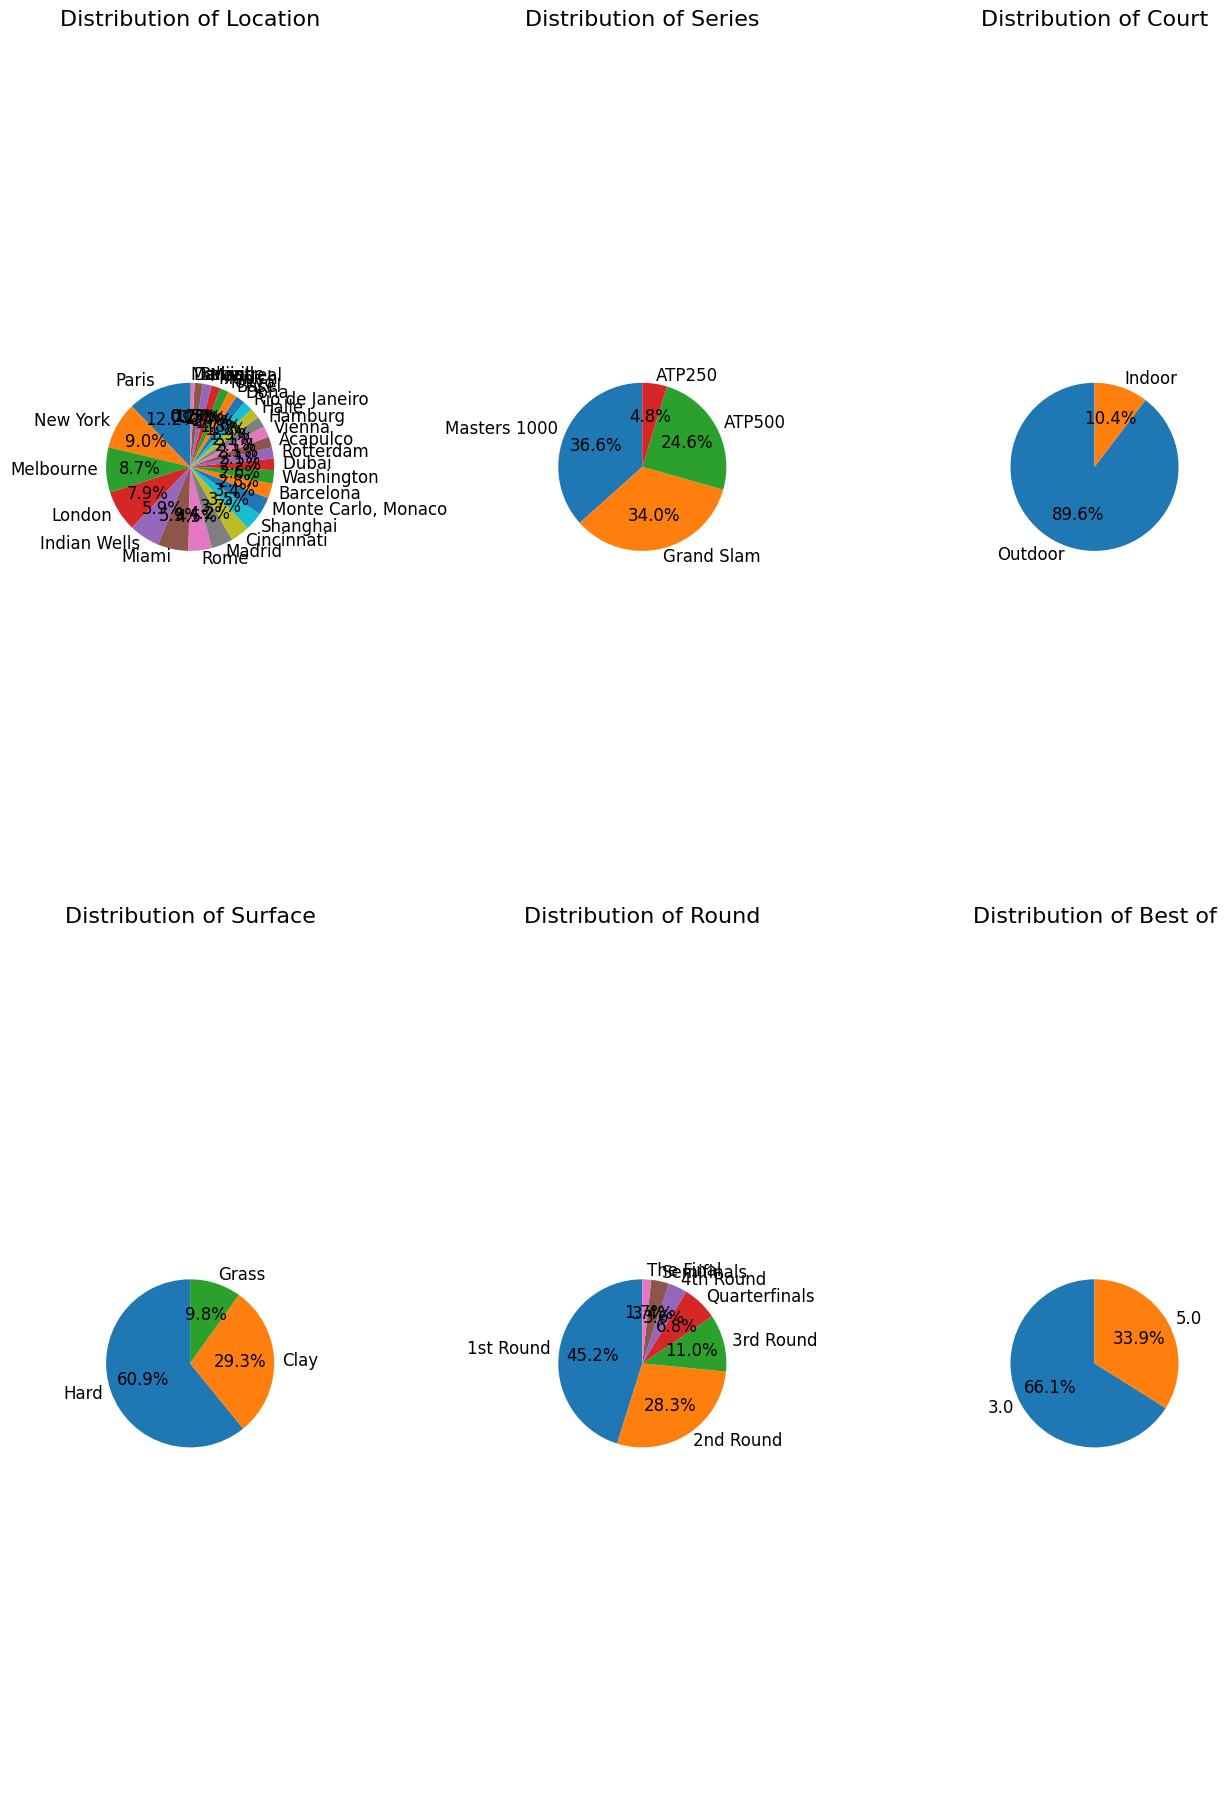

In [38]:
vars_cat = ['Location', 'Series', 'Court', 'Surface', 'Round', 'Best of']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,18))
axes = axes.flatten()

for i, var in enumerate(vars_cat):
  axes[i].pie(df[var].value_counts(),
              labels=df[var].value_counts().index,
              autopct='%1.1f%%',
              startangle=90,
              textprops={'fontsize': 12})
  axes[i].set_title(f'Distribution of {var}', fontsize=16)
  axes[i].axis('equal')

# Hide any unused subplots
for j in range(len(vars_cat), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=0.5) # Reduced padding to bring titles closer
plt.show()

*Insights*:
- Las ciudades tiene más o menos la misma cantidad de partidos. Seguramente dependiendo de la cantidad de partidos del torneo hayan acumulado más o menos partidos a lo largo de los años que comprende el dataset
- Tenemos partidos de Grand Slam, Masters 1000 y ATP500 en proporciones similares. Pero de ATP250 no extrajimos datos, ¿cómo es eso posible?
- Casi siempre se juega afuera: el 90% de los partidos
- El pasto como superficie es inusual, algo que tiene mucho sentido si lo analizamos desde un punto de vista tenístico, y la superficie dura abunda como predominante
- Las primeras dos rondas son las que tienen más partidos: lógico, a medida que avanzan las rondas quedan menos participantes y por ende hay menos partidos
- La mayoría de partidos son a 3 sets. Esto tiene correlación intrínseca con el nivel del torneo

Observamos esta curiosidad. Cuando hicimos el scraping, scrapeamos a torneos ATP 500 o superior. Pero como extrajimos los últimos 10 años ocurrió que algunos torneos cambiaron de status (de ATP 250 subieron a ser ATP 500) hace menos tiempo entonces también se registran partidos de ese nivel. Los dejamos en la base.

In [39]:
df['Series'].value_counts()

Series
Masters 1000    5884
Grand Slam      5459
ATP500          3954
ATP250           764
Name: count, dtype: int64

In [40]:
# Ciudades que registran partidos de ATP250
df[df['Series'] == 'ATP250']['Location'].value_counts()

Location
Doha         263
Munich       243
Hamburg      119
Dallas        81
Vienna        31
Marseille     27
Name: count, dtype: int64

Comparamos la cantidad de partidos por ciudad

In [41]:
pd.DataFrame(df['Location'].value_counts()).T

Location,Paris,New York,Melbourne,London,Indian Wells,Miami,Rome,Madrid,Cincinnati,Shanghai,"Monte Carlo, Monaco",Barcelona,Washington,Dubai,Rotterdam,Acapulco,Vienna,Hamburg,Halle,Rio de Janeiro,Doha,Basel,Tokyo,Munich,Montreal,Beijing,Dallas,Marseille
count,1960,1451,1397,1270,950,950,724,670,590,560,548,454,423,355,341,341,341,336,310,304,294,279,279,274,273,248,112,27


## Análisis Numéricas

Variable ATP Ranking
- Distribución muy asimétrica a derecha

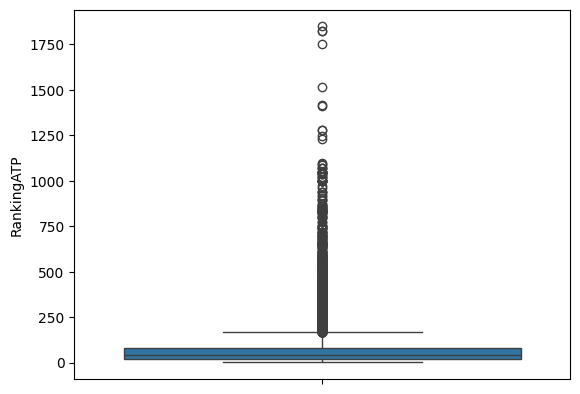

In [42]:
rankATP = pd.concat([df['rankA'], df['rankB']], axis=0).rename('RankingATP')
sns.boxplot(data=rankATP)
plt.show()

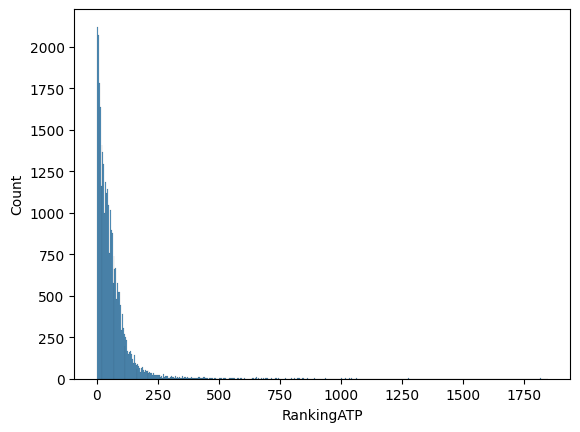

In [43]:
sns.histplot(rankATP)
plt.show()

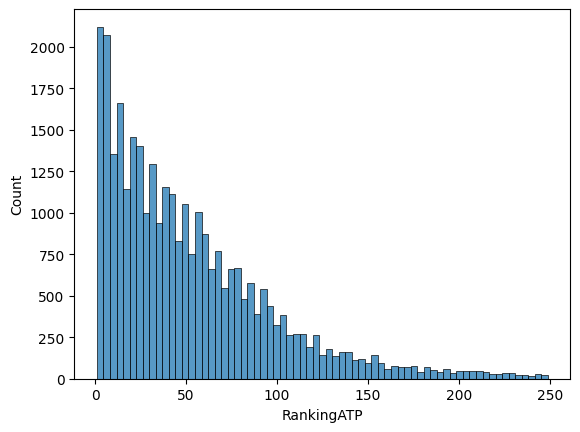

In [44]:
sns.histplot(rankATP[rankATP<250])
plt.show()

Variables relacionadas a Odds:

- Odds de B365 tienen mucha asimetría a derecha. Hay algunos outliers que podríamos ver de sacar

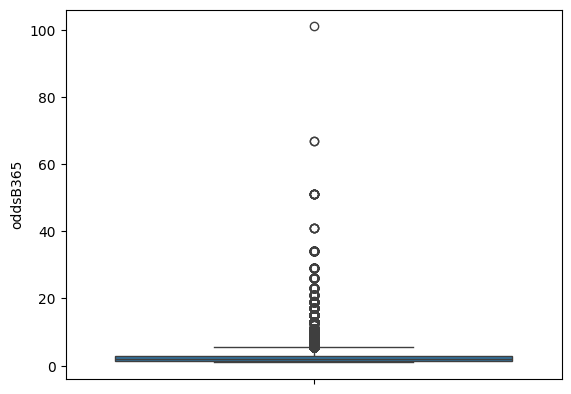

In [45]:
oddsB365 = pd.concat([df['B365A'], df['B365B']], axis=0).rename('oddsB365')
sns.boxplot(data=oddsB365)
plt.show()

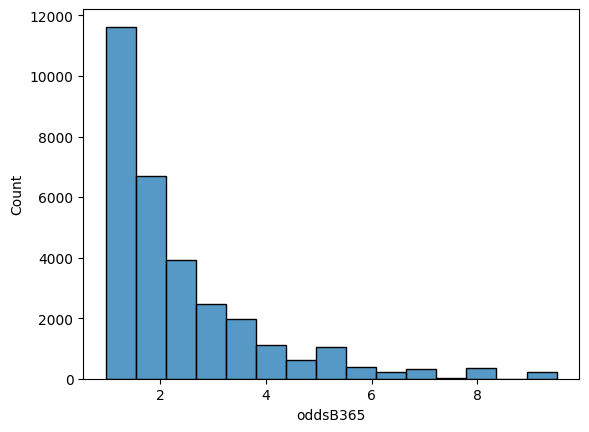

In [46]:
sns.histplot(oddsB365[oddsB365<10], bins=15)
plt.show()

In [47]:
# Vemos los partidos cuando hubo odds > 50 -> algunos se van porque no tienen partidos previos (-> % victorias previas es NaN) y otros estan ok, tiene logica

# df[(df['B365A'] > 50) | (df['B365B'] > 50)]

- Max Odds: distribución bien asimétrica a derecha. Corregimos 2 outliers

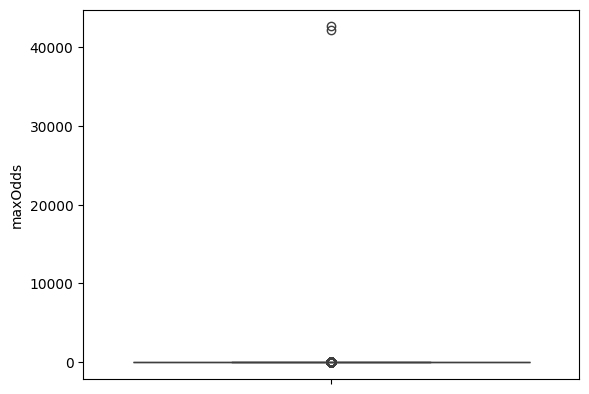

In [48]:
maxOdds = pd.concat([df['MaxA'], df['MaxB']], axis=0).rename('maxOdds')
sns.boxplot(data=maxOdds)
plt.show()

In [49]:
mask = (df['MaxA']>100) | (df['MaxB']>100)
df.loc[mask, ['MaxA']] = df.loc[mask].apply(lambda row: row['B365A'] if row['B365A']>row['AvgA'] else row['AvgA'], axis=1)
df.loc[mask, ['MaxB']] = df.loc[mask].apply(lambda row: row['B365B'] if row['B365B']>row['AvgB'] else row['AvgB'], axis=1)

# Volvemos a crear maxOdds
maxOdds = pd.concat([df['MaxA'], df['MaxB']], axis=0).rename('maxOdds')

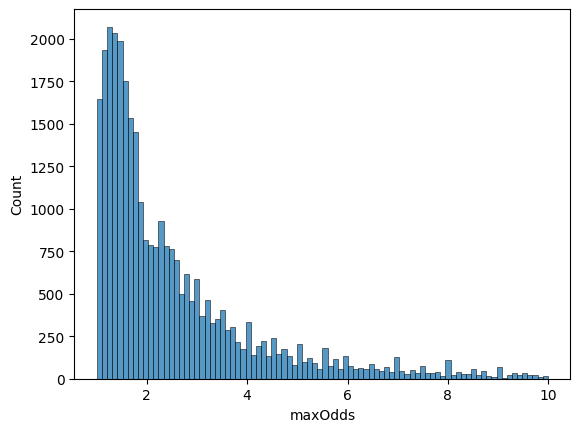

In [50]:
sns.histplot(maxOdds[maxOdds<10])
plt.show()

Variable Market Uncertainty: la mayoría de los partidos son bastante parejos

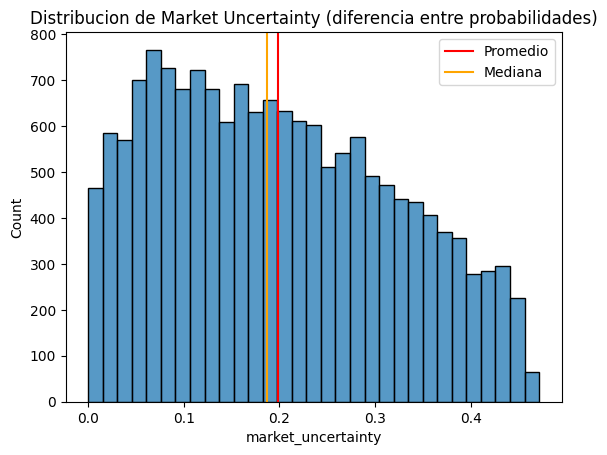

In [51]:
plt.title('Distribucion de Market Uncertainty (diferencia entre probabilidades)')
sns.histplot(df['market_uncertainty'])
plt.axvline(x=df['market_uncertainty'].mean(), color='red', label='Promedio')
plt.axvline(x=df['market_uncertainty'].median(), color='orange', label='Mediana')
plt.legend()
plt.show()

Corrección que notamos:

In [64]:
print(f'Hay {df[((df['MaxA'] - df['AvgA']) < 0) | ((df['MaxB'] - df['AvgB']) < 0)].shape[0]} registros con cuotas Max menores que Avg, lo que no tiene sentido')

Hay 8 registros con cuotas Max menores que Avg, lo que no tiene sentido


Por ende, los corregimos:

In [75]:
df.loc[(df['MaxA'] - df['AvgA']) < 0, 'MaxA'] = df.loc[(df['MaxA'] - df['AvgA']) < 0, 'AvgA']
df.loc[(df['MaxB'] - df['AvgB']) < 0, 'MaxB'] = df.loc[(df['MaxB'] - df['AvgB']) < 0, 'AvgB']

In [80]:
df.to_csv('pre_ml_df.csv', index=False)